In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('credit_risk_dataset.csv')
data = df.copy()

In [27]:
data.head()

,customer_id,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,CUST_00000,58,Male,Unemployed,58137.751192,115,524.679407,1,171.342369,49,768.877511,9,16,1,539,5,14435.423445,2,0,0,15510.576882,1
1,CUST_00001,48,Male,Self-Employed,26174.922827,32,2635.203357,1,985.607164,1,580.287785,9,1,2,494,5,11263.099341,2,0,0,14819.436498,1
2,CUST_00002,34,Other,Unemployed,75566.837265,14,2334.341061,9,994.310119,42,564.013508,36,5,6,437,3,15017.144132,5,0,0,10909.806507,1
3,CUST_00003,62,Male,Self-Employed,35197.961516,179,2425.384332,10,366.115346,4,838.489200,31,7,7,809,1,12626.138476,2,0,0,500.000000,0
4,CUST_00004,27,Female,Self-Employed,12136.998349,225,10.000000,8,786.752258,16,462.495522,35,16,3,522,1,13576.704320,4,0,0,9514.591618,1


In [29]:
data.drop('customer_id', inplace = True, axis = 1)

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   employment_status           5000 non-null   object 
 3   annual_income               5000 non-null   float64
 4   account_age_months          5000 non-null   int64  
 5   avg_monthly_balance         5000 non-null   float64
 6   num_deposits_per_month      5000 non-null   int64  
 7   avg_deposit_amount          5000 non-null   float64
 8   debit_card_usage_frequency  5000 non-null   int64  
 9   debit_card_spending         5000 non-null   float64
 10  mobile_banking_logins       5000 non-null   int64  
 11  online_transfer_frequency   5000 non-null   int64  
 12  atm_withdrawal_frequency    5000 non-null   int64  
 13  credit_score                5000 

In [87]:
data.shape

(5000, 21)

In [89]:
data.size

105000

In [78]:
data['loan_default_history'].value_counts()

loan_default_history
0    4513
1     487
Name: count, dtype: int64

In [81]:
data['fraud_flag'].value_counts()

fraud_flag
0    4857
1     143
Name: count, dtype: int64

In [83]:
data['credit_risk'].value_counts()

credit_risk
1    3829
0    1171
Name: count, dtype: int64

------------------------------------------
- **No null values in the dataset**
- **Need to round the decimal places in float dtype columns to reduce the redundancy in the computations**
- **Need to change the dtypes of binary columns to object type ('loan_default_history', 'fraud_flag', 'credit_risk')**
-----------------------------------------

In [65]:
data['fraud_flag'].nunique()

2

In [75]:
binary_cols = [col for col in data.columns if data[col].nunique() == 2]
data[binary_cols] = data[binary_cols].astype('O')
data[binary_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   loan_default_history  5000 non-null   object
 1   fraud_flag            5000 non-null   object
 2   credit_risk           5000 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB


In [85]:
data.describe()

,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_application_amount
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,44.666600,49870.073918,121.226800,1500.912702,5.542000,800.663424,24.424800,500.284826,39.028000,9.660600,4.55720,599.328200,2.480800,12173.548620,3.46940,8149.415742
std,14.384312,17831.984781,68.325584,772.243457,3.424118,341.229691,14.395172,245.167886,23.039457,5.858248,2.89109,174.345499,1.698649,5993.358852,2.29332,4309.579461
min,20.000000,10000.000000,3.000000,10.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.00000,300.000000,0.000000,0.000000,0.00000,500.000000
25%,32.000000,37633.480000,62.000000,958.525000,3.000000,559.312500,12.000000,328.342500,19.000000,4.000000,2.00000,447.000000,1.000000,8076.727500,1.00000,4993.477500
50%,45.000000,49682.455000,120.500000,1486.065000,6.000000,802.695000,25.000000,498.755000,39.000000,10.000000,5.00000,597.000000,2.000000,12196.805000,3.00000,8039.115000
75%,57.000000,61964.225000,181.000000,2024.760000,9.000000,1033.797500,37.000000,664.060000,58.000000,15.000000,7.00000,753.000000,4.000000,16279.962500,5.00000,11160.810000
max,69.000000,113793.170000,239.000000,4818.320000,11.000000,1925.380000,49.000000,1379.490000,79.000000,19.000000,9.00000,899.000000,5.000000,32433.860000,7.00000,25622.340000


In [35]:
data.describe(include = 'O')

,gender,employment_status
count,5000,5000
unique,3,3
top,Female,Employed
freq,1705,1746


### Rounding to 2 Decimal Places for float dtype columns

In [95]:
float_dtype_cols = [col for col in data.columns if data[col].dtype == np.float64]


In [97]:
data[float_dtype_cols] = data[float_dtype_cols].round(2)

In [99]:
data.head()

,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,58,Male,Unemployed,58137.75,115,524.68,1,171.34,49,768.88,9,16,1,539,5,14435.42,2,0,0,15510.58,1
1,48,Male,Self-Employed,26174.92,32,2635.20,1,985.61,1,580.29,9,1,2,494,5,11263.10,2,0,0,14819.44,1
2,34,Other,Unemployed,75566.84,14,2334.34,9,994.31,42,564.01,36,5,6,437,3,15017.14,5,0,0,10909.81,1
3,62,Male,Self-Employed,35197.96,179,2425.38,10,366.12,4,838.49,31,7,7,809,1,12626.14,2,0,0,500.00,0
4,27,Female,Self-Employed,12137.00,225,10.00,8,786.75,16,462.50,35,16,3,522,1,13576.70,4,0,0,9514.59,1


In [105]:
# avg_deposit_amount          -->    Average value of deposits
# debit_card_usage_frequency  -->    Total debit card transaction count per month
# debit_card_spending         -->    Monthly spending through debit card transactions
# mobile_banking_logins       -->    Number of times customer logs into mobile banking
# online_transfer_frequency   -->    Number of online fund transfers per month
# atm_withdrawal_frequency    -->    ATM withdrawals per month  
# total_outstanding_debt      -->    Total amount of unpaid debt

In [109]:
data.duplicated().sum()

0

- **Found no duplicates in the dataset**

In [114]:
data[data.duplicated()]

,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk


- **Checking Missing Values**

In [119]:
data.isnull().sum()/len(data) * 100

age                           0.0
gender                        0.0
employment_status             0.0
annual_income                 0.0
account_age_months            0.0
avg_monthly_balance           0.0
num_deposits_per_month        0.0
avg_deposit_amount            0.0
debit_card_usage_frequency    0.0
debit_card_spending           0.0
mobile_banking_logins         0.0
online_transfer_frequency     0.0
atm_withdrawal_frequency      0.0
credit_score                  0.0
num_open_loans                0.0
total_outstanding_debt        0.0
late_payment_count            0.0
loan_default_history          0.0
fraud_flag                    0.0
loan_application_amount       0.0
credit_risk                   0.0
dtype: float64

- **Checking no.of unique values (cardinality)**

In [124]:
data.nunique()

age                             50
gender                           3
employment_status                3
annual_income                 4930
account_age_months             237
avg_monthly_balance           4805
num_deposits_per_month          12
avg_deposit_amount            4861
debit_card_usage_frequency      50
debit_card_spending           4747
mobile_banking_logins           80
online_transfer_frequency       20
atm_withdrawal_frequency        10
credit_score                   600
num_open_loans                   6
total_outstanding_debt        4875
late_payment_count               8
loan_default_history             2
fraud_flag                       2
loan_application_amount       4753
credit_risk                      2
dtype: int64

In [135]:
cat_cols = data.select_dtypes(include='O').columns.to_list()
data[cat_cols].head()

,gender,employment_status,loan_default_history,fraud_flag,credit_risk
0,Male,Unemployed,0,0,1
1,Male,Self-Employed,0,0,1
2,Other,Unemployed,0,0,1
3,Male,Self-Employed,0,0,0
4,Female,Self-Employed,0,0,1


In [163]:
for col in cat_cols:
    print(f'\nUnique values in {col} are: \n', data[col].value_counts())


Unique values in gender are: 
 gender
Female    1705
Other     1680
Male      1615
Name: count, dtype: int64

Unique values in employment_status are: 
 employment_status
Employed         1746
Self-Employed    1633
Unemployed       1621
Name: count, dtype: int64

Unique values in loan_default_history are: 
 loan_default_history
0    4513
1     487
Name: count, dtype: int64

Unique values in fraud_flag are: 
 fraud_flag
0    4857
1     143
Name: count, dtype: int64

Unique values in credit_risk are: 
 credit_risk
1    3829
0    1171
Name: count, dtype: int64


- **Checking for class balance in Target Column**

In [166]:
data['credit_risk'].value_counts(normalize=True) * 100   # In percentages

credit_risk
1    76.58
0    23.42
Name: proportion, dtype: float64

In [168]:
# As there is a class imbalance

at_risk = data[data['credit_risk'] == 1]
at_risk.describe()

,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_application_amount
count,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000
mean,44.642988,49995.723612,121.871768,1502.344260,5.559937,802.158107,24.345782,502.974730,39.092975,9.638026,4.584487,556.049099,2.487595,12197.670543,4.082267,8195.866075
std,14.419116,17846.025962,67.974010,766.219169,3.427236,339.981674,14.352957,246.548116,22.960332,5.886294,2.896414,170.550394,1.692588,5977.106361,2.209926,4288.500270
min,20.000000,10000.000000,3.000000,10.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,0.000000,0.000000,0.000000,500.000000
25%,32.000000,37701.810000,62.000000,962.660000,3.000000,563.120000,12.000000,326.520000,19.000000,4.000000,2.000000,413.000000,1.000000,8141.460000,2.000000,5042.680000
50%,45.000000,50085.380000,121.000000,1495.500000,6.000000,805.400000,25.000000,500.340000,39.000000,10.000000,5.000000,525.000000,2.000000,12226.690000,4.000000,8051.180000
75%,57.000000,62464.360000,181.000000,2027.700000,9.000000,1031.080000,37.000000,667.160000,58.000000,15.000000,7.000000,693.000000,4.000000,16317.030000,6.000000,11185.450000
max,69.000000,113793.170000,239.000000,4818.320000,11.000000,1925.380000,49.000000,1379.490000,79.000000,19.000000,9.000000,899.000000,5.000000,31088.020000,7.000000,25622.340000


In [170]:
no_risk = data[data['credit_risk'] == 0]
no_risk.describe()

,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_application_amount
count,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000
mean,44.743809,49459.217660,119.117848,1496.231716,5.483348,795.776029,24.683177,491.489231,38.815542,9.734415,4.467976,740.844577,2.458582,12094.673433,1.465414,7997.529898
std,14.275768,17787.405673,69.450307,791.937172,3.414702,345.380318,14.535528,240.493354,23.304931,5.767460,2.873032,92.362865,1.718860,6048.094569,1.115297,4376.206207
min,20.000000,10000.000000,3.000000,10.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,580.000000,0.000000,0.000000,0.000000,500.000000
25%,33.000000,37490.155000,57.000000,945.955000,3.000000,547.215000,12.000000,334.235000,19.000000,5.000000,2.000000,660.000000,1.000000,7809.735000,0.000000,4750.755000
50%,45.000000,48821.830000,117.000000,1466.780000,5.000000,792.030000,24.000000,492.500000,38.000000,10.000000,4.000000,746.000000,2.000000,12065.850000,1.000000,8000.360000
75%,57.000000,60677.745000,182.000000,2009.345000,8.000000,1035.745000,37.000000,652.565000,58.000000,15.000000,7.000000,819.000000,4.000000,16198.590000,2.000000,10992.725000
max,69.000000,105215.040000,239.000000,4113.780000,11.000000,1905.630000,49.000000,1237.250000,79.000000,19.000000,9.000000,899.000000,5.000000,32433.860000,3.000000,21071.930000


<Axes: xlabel='credit_risk', ylabel='age'>

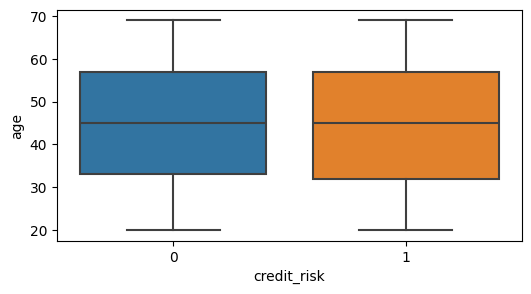

In [180]:
plt.figure(figsize=(6,3))
sns.boxplot(x = 'credit_risk', y = 'age', data=data)

<Axes: xlabel='credit_risk', ylabel='credit_score'>

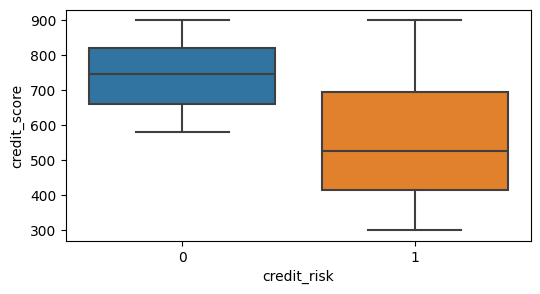

In [182]:
plt.figure(figsize=(6,3))
sns.boxplot(x = 'credit_risk', y = 'credit_score', data=data)

## Exploratory Data Analysis

#### Univariate Analysis